In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "sst2"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence', 'label', 'idx'],
    num_rows: 67349
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence': 'hide new secretions from the parental units ',
 'label': 0,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence']

"that 's far too tragic to merit such superficial treatment "

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence': Value('string'),
 'label': ClassLabel(names=['negative', 'positive']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 47]),
 'token_type_ids': torch.Size([32, 47]),
 'attention_mask': torch.Size([32, 47])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [21]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [22]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [23]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [25]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7323, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [26]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [27]:
load_path = './glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [28]:
from train_eval_func import eval_loop

In [29]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9311926605504587}

# 5. Importance Score Eval

In [30]:
from structure_prune_helper import compute_importance_scores

In [31]:
from structure_prune_helper import compute_importance_scores, register_importance_masks, remove_importance_masks

In [32]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

  Layer 0: Registered masks (12 heads, 3072 neurons)
  Layer 1: Registered masks (12 heads, 3072 neurons)
  Layer 2: Registered masks (12 heads, 3072 neurons)
  Layer 3: Registered masks (12 heads, 3072 neurons)
  Layer 4: Registered masks (12 heads, 3072 neurons)
  Layer 5: Registered masks (12 heads, 3072 neurons)
  Layer 6: Registered masks (12 heads, 3072 neurons)
  Layer 7: Registered masks (12 heads, 3072 neurons)
  Layer 8: Registered masks (12 heads, 3072 neurons)
  Layer 9: Registered masks (12 heads, 3072 neurons)
  Layer 10: Registered masks (12 heads, 3072 neurons)
  Layer 11: Registered masks (12 heads, 3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [33]:
head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True, max_batches=115)

Computing importance (heads + FFN): 100%|██████████| 115/115 [00:12<00:00,  9.53it/s]


In [34]:
head_importance

[tensor([1.2301e-05, 1.0361e-05, 1.0909e-05, 8.9985e-06, 1.0604e-05, 1.1708e-05,
         9.7197e-06, 1.1503e-05, 1.8053e-05, 1.5297e-05, 1.3680e-05, 9.1153e-06],
        device='cuda:1'),
 tensor([6.8117e-06, 2.1313e-05, 5.4860e-06, 6.2763e-06, 1.2896e-05, 4.7952e-06,
         4.9895e-06, 7.6332e-06, 4.1576e-06, 6.8901e-06, 7.8392e-06, 8.4807e-06],
        device='cuda:1'),
 tensor([1.3582e-05, 7.7879e-06, 5.2574e-06, 3.3726e-06, 4.4072e-06, 4.1142e-06,
         8.4911e-06, 4.4309e-06, 4.5122e-06, 1.2882e-05, 5.7914e-06, 6.6130e-06],
        device='cuda:1'),
 tensor([5.3671e-06, 6.2633e-06, 3.5807e-06, 6.0638e-06, 3.5921e-06, 1.1866e-05,
         8.8365e-06, 4.5547e-06, 7.3326e-06, 8.9971e-06, 9.0828e-06, 6.1774e-06],
        device='cuda:1'),
 tensor([1.0699e-05, 3.0772e-06, 4.0247e-06, 3.2471e-06, 7.6933e-06, 6.0824e-06,
         6.8121e-06, 1.0809e-05, 2.5768e-06, 7.8502e-06, 6.2454e-06, 7.0991e-06],
        device='cuda:1'),
 tensor([9.3818e-06, 4.4720e-06, 2.8166e-06, 4.7226e-06

In [35]:
import matplotlib.pyplot as plt

In [36]:
head_scores = torch.stack(head_importance).cpu()

# Sum all heads inside each layer
layer_scores = head_scores.sum(dim=1)

print(layer_scores.shape)  # [6]
print(layer_scores)

torch.Size([12])
tensor([1.4225e-04, 9.7569e-05, 8.1241e-05, 8.1715e-05, 7.6216e-05, 8.0824e-05,
        8.5957e-05, 8.1846e-05, 7.5906e-05, 6.9585e-05, 4.2532e-05, 4.9133e-05])


In [37]:
normalized_scores = (
    (layer_scores - layer_scores.min())
    / (layer_scores.max() - layer_scores.min())
)
normalized_scores

tensor([1.0000, 0.5519, 0.3882, 0.3929, 0.3378, 0.3840, 0.4355, 0.3943, 0.3347,
        0.2713, 0.0000, 0.0662])

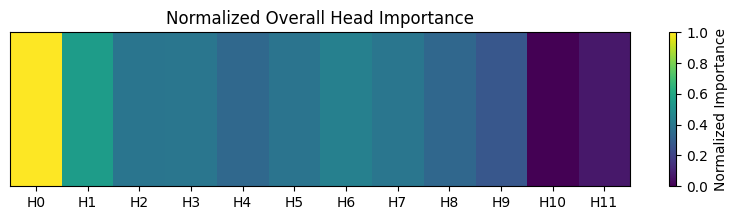

In [39]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall Head Importance")

plt.show()

In [40]:
import torch.nn as nn

In [41]:
model.bert.encoder.layer = nn.ModuleList(
    [layer for i, layer in enumerate(model.bert.encoder.layer) if i != 4]
)
model.config.num_hidden_layers = len(model.bert.encoder.layer)

In [42]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8455882352941176, 'f1': 0.8856624319419237}

In [78]:
int(torch.min(normalized_scores))

0

In [79]:
normalized_scores

tensor([0.9020, 0.9605, 0.9304, 1.0000, 0.6415, 0.9053, 0.2866, 0.1900, 0.2769,
        0.2527, 0.0328, 0.0000])

In [80]:
torch.argmin(normalized_scores)

tensor(0.)